IMPORT LIBRARY

In [5]:
# Import library
import os
import cv2
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
import torch
import timm

# library evaluasi
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
warnings.filterwarnings("ignore")
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2


PATH DATASET

In [6]:
# Hubungkan Dengan Drive
from google.colab import drive
drive.mount('/content/drive')

# Menentukan path dataset
dataset_path = "/content/drive/MyDrive/PROJECT AI/MENTAH DATASET/Dataset makanan"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PREPROCESING

In [7]:
# PREPROCESSING DATA

# Preprocessing data training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing data validasi dan testing
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

# Ukuran citra
IMG_SIZE = (256, 256)

# Data training
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='categorical',
    shuffle=False,
    seed=24
)

# Data validasi
val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='categorical',
    shuffle=False,
    seed=24
)

# Data testing
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='categorical',
    shuffle=False,
    seed=24
)

# Mengambil label
y_train = train_generator.classes
y_val = val_generator.classes
y_test = test_generator.classes

# Menampilkan informasi dataset
print("Jumlah data training  :", len(y_train))
print("Jumlah data validasi  :", len(y_val))
print("Jumlah data testing   :", len(y_test))
print("Jumlah kelas          :", len(train_generator.class_indices))
print("Nama kelas            :", list(train_generator.class_indices.keys()))

Found 3988 images belonging to 15 classes.
Found 495 images belonging to 15 classes.
Found 508 images belonging to 15 classes.
Jumlah data training  : 3988
Jumlah data validasi  : 495
Jumlah data testing   : 508
Jumlah kelas          : 15
Nama kelas            : ['Ayam_Goreng', 'Bika_Ambon', 'Gado_Gado', 'Gudeg', 'Kerak_Telor', 'Kolak', 'Lumpia', 'Nasi_Goreng', 'Papeda', 'Pempek', 'Rendang', 'Rujak_Cingur', 'Sate_Ayam', 'Serabi', 'Soto']


EKSTRASI FITUR

In [9]:
# Memuat library
import numpy as np
import torch
import timm

from PIL import Image
from tqdm.auto import tqdm
from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform

# Memuat model ResNet50 Food101
feature_extractor = timm.create_model(
    "hf_hub:anonauthors/food101-resnet50",
    pretrained=True,
    num_classes=0
)

# Freeze seluruh parameter
for param in feature_extractor.parameters():
    param.requires_grad = False

# Mode evaluasi
feature_extractor.eval()

# Menggunakan GPU jika tersedia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# Transform bawaan model
data_config = resolve_model_data_config(feature_extractor)
transform = create_transform(**data_config)

# Fungsi ekstraksi fitur
def extract_features(generator, model, transform, device, desc):

    features = []

    generator.reset()

    with torch.no_grad():

        progress_bar = tqdm(
            total=len(generator),
            desc=desc,
            unit="batch",
            colour="green"
        )

        for i in range(len(generator)):

            images, _ = generator[i]

            # Preprocessing seluruh gambar dalam satu batch
            batch = torch.stack([
                transform(
                    Image.fromarray(img.astype(np.uint8))
                )
                for img in images
            ]).to(device)

            # Ekstraksi fitur satu batch sekaligus
            batch_features = model(batch)

            # Menyimpan hasil ekstraksi
            features.extend(
                batch_features.cpu().numpy()
            )

            progress_bar.update(1)

        progress_bar.close()

    return np.array(features)

# Ekstraksi fitur data training
print("\nMemulai ekstraksi fitur data training...")
X_train_feature = extract_features(
    train_generator,
    feature_extractor,
    transform,
    device,
    desc="Training"
)

# Ekstraksi fitur data validasi
print("\nMemulai ekstraksi fitur data validasi...")
X_val_feature = extract_features(
    val_generator,
    feature_extractor,
    transform,
    device,
    desc="Validation"
)

# Ekstraksi fitur data testing
print("\nMemulai ekstraksi fitur data testing...")
X_test_feature = extract_features(
    test_generator,
    feature_extractor,
    transform,
    device,
    desc="Testing"
)

# Mengambil label
y_train = train_generator.classes
y_val = val_generator.classes
y_test = test_generator.classes

# Menampilkan hasil ekstraksi fitur
print("\n========== HASIL EKSTRAKSI FITUR ==========")
print("Training Feature   :", X_train_feature.shape)
print("Validation Feature :", X_val_feature.shape)
print("Testing Feature    :", X_test_feature.shape)
print("\n========== JUMLAH LABEL ==========")
print("Training Label     :", y_train.shape)
print("Validation Label   :", y_val.shape)
print("Testing Label      :", y_test.shape)

Device : cuda
GPU    : Tesla T4

Memulai ekstraksi fitur data training...


Training:   0%|          | 0/250 [00:00<?, ?batch/s]


Memulai ekstraksi fitur data validasi...


Validation:   0%|          | 0/31 [00:00<?, ?batch/s]


Memulai ekstraksi fitur data testing...


Testing:   0%|          | 0/32 [00:00<?, ?batch/s]


========== HASIL EKSTRAKSI FITUR ==========
Training Feature   : (3988, 2048)
Validation Feature : (495, 2048)
Testing Feature    : (508, 2048)

========== JUMLAH LABEL ==========
Training Label     : (3988,)
Validation Label   : (495,)
Testing Label      : (508,)


SCALING FITUR

In [10]:
# Melakukan standardisasi fitur
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_feature)
X_val_scaled = scaler.transform(X_val_feature)
X_test_scaled = scaler.transform(X_test_feature)

# Menampilkan ukuran fitur setelah standardisasi
print("Training :", X_train_scaled.shape)
print("Validation :", X_val_scaled.shape)
print("Testing :", X_test_scaled.shape)

Training : (3988, 2048)
Validation : (495, 2048)
Testing : (508, 2048)


TRAINING DAN TUNNING SVM

In [31]:
# Memuat library
from sklearn.svm import SVC
import time

# Membuat model SVM
svm_model = SVC(
    kernel='rbf',
    C=100,
    gamma='scale',
    probability=True,
    random_state=24
)

print("Memulai proses training SVM...")

# Menghitung waktu training
start_time = time.time()

# Melatih model
svm_model.fit(X_train_scaled, y_train)

# Menghitung lama training
end_time = time.time()
training_time = end_time - start_time
print("Training SVM selesai.")
print(f"Waktu Training : {training_time:.2f} detik")

Memulai proses training SVM...
Training SVM selesai.
Waktu Training : 66.49 detik


HASIL DAN EVALUASI VALIDASI

========== HASIL EVALUASI VALIDASI ==========
Akurasi  : 0.8687
Presisi  : 0.8786
Recall   : 0.8687
F1-Score : 0.8671

Classification Report
              precision    recall  f1-score   support

 Ayam_Goreng       0.89      0.76      0.82        33
  Bika_Ambon       0.94      0.88      0.91        34
   Gado_Gado       0.70      0.76      0.73        34
       Gudeg       0.82      0.97      0.89        34
 Kerak_Telor       0.94      1.00      0.97        32
       Kolak       0.82      1.00      0.90        32
      Lumpia       1.00      0.94      0.97        33
 Nasi_Goreng       1.00      0.76      0.87        34
      Papeda       0.77      0.94      0.85        32
      Pempek       0.94      0.88      0.91        33
     Rendang       0.90      0.79      0.84        33
Rujak_Cingur       0.95      0.59      0.73        32
   Sate_Ayam       0.76      0.88      0.82        33
      Serabi       0.85      0.91      0.88        32
        Soto       0.89      0.97      0.93     

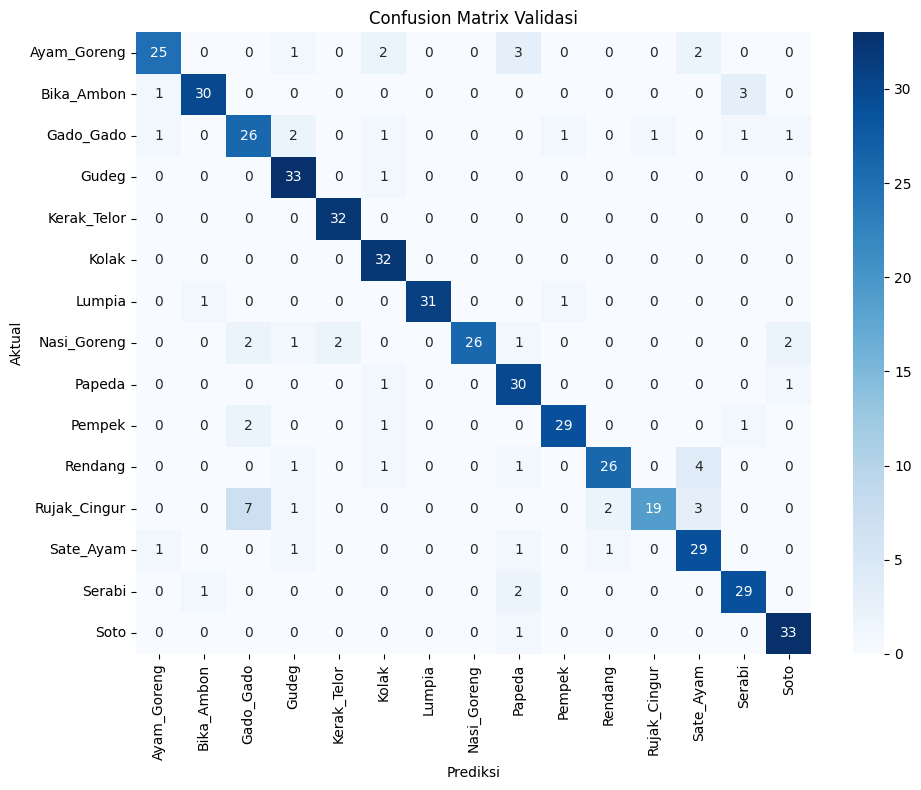


ROC-AUC Validasi (Macro): 0.9928


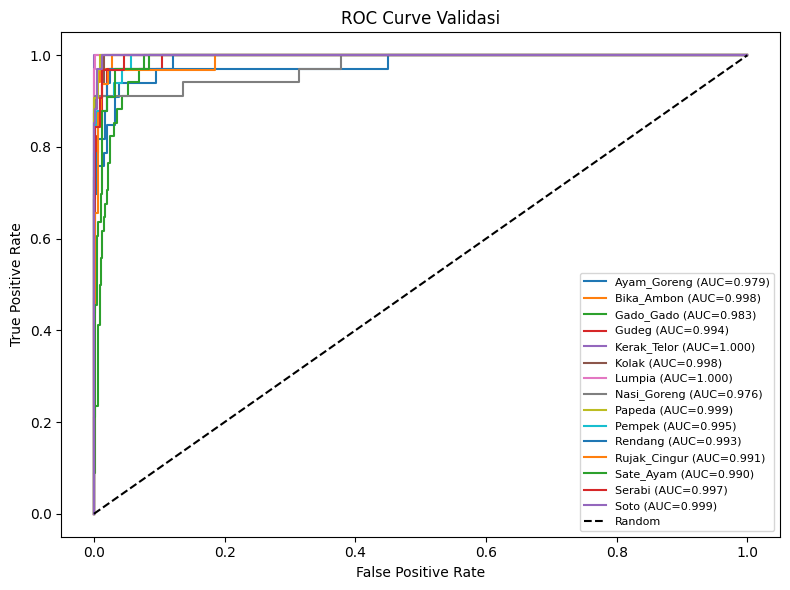

In [32]:
# EVALUASI DATA VALIDASI

# Prediksi data validasi
y_val_pred = svm_model.predict(X_val_scaled)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, average="weighted")
recall = recall_score(y_val, y_val_pred, average="weighted")
f1 = f1_score(y_val, y_val_pred, average="weighted")

print("========== HASIL EVALUASI VALIDASI ==========")
print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report
print("\nClassification Report")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=list(val_generator.class_indices.keys())
))

# CONFUSION MATRIX

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(val_generator.class_indices.keys()),
    yticklabels=list(val_generator.class_indices.keys())
)

plt.title("Confusion Matrix Validasi")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

# ROC-AUC

classes = np.unique(y_val)
y_val_bin = label_binarize(
    y_val,
    classes=classes
)

y_val_score = svm_model.predict_proba(X_val_scaled)

roc_auc = roc_auc_score(
    y_val_bin,
    y_val_score,
    multi_class="ovr",
    average="macro"
)

print(f"\nROC-AUC Validasi (Macro): {roc_auc:.4f}")

# ROC CURVE

plt.figure(figsize=(8, 6))
for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_val_bin[:, i],
        y_val_score[:, i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{list(val_generator.class_indices.keys())[i]} (AUC={auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.title("ROC Curve Validasi")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

HASIL DAN EVALUASI TEST

========== HASIL EVALUASI TESTING ==========
Akurasi  : 0.8622
Presisi  : 0.8653
Recall   : 0.8622
F1-Score : 0.8604

Classification Report
                      precision    recall  f1-score   support

Ayam_Goreng_Lengkuas       0.82      0.79      0.81        34
          Bika_Ambon       1.00      0.86      0.92        35
           Gado_Gado       0.76      0.65      0.70        34
               Gudeg       0.83      0.71      0.76        34
         Kerak_Telor       0.91      0.94      0.92        32
               Kolak       0.83      1.00      0.91        34
              Lumpia       0.97      1.00      0.99        35
         Nasi_Goreng       1.00      0.79      0.89        34
              Papeda       0.86      0.94      0.90        32
              Pempek       0.94      0.89      0.91        35
             Rendang       0.83      0.88      0.86        34
        Rujak_Cingur       0.70      0.72      0.71        32
           Sate_Ayam       0.82      0.80      0.81  

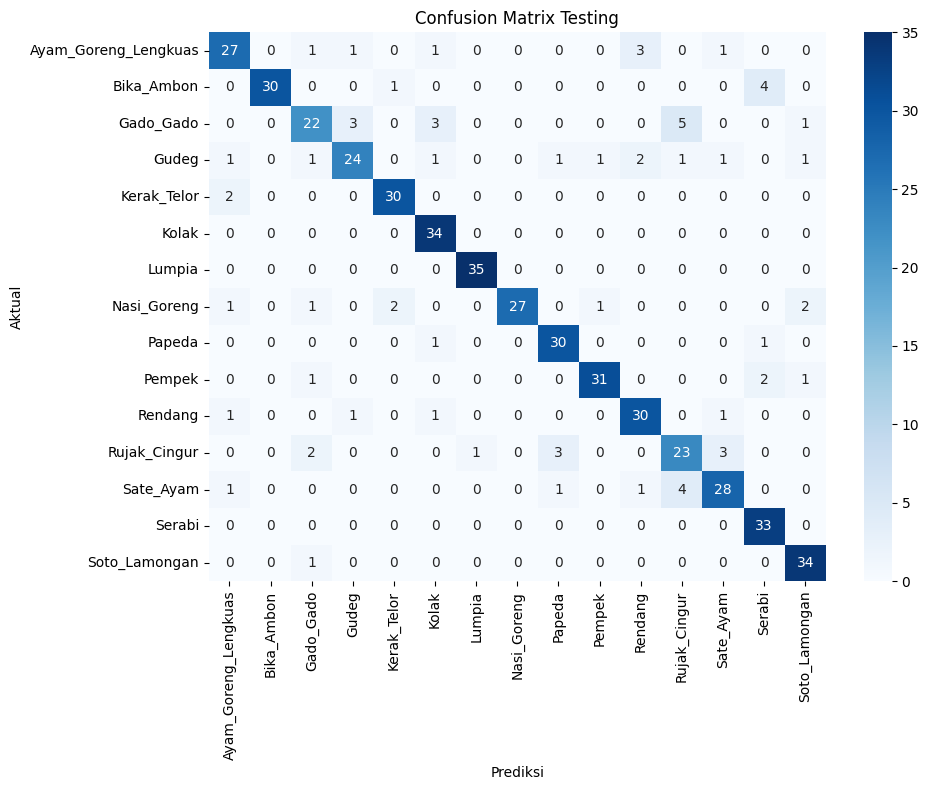


ROC-AUC Testing (Macro): 0.9935


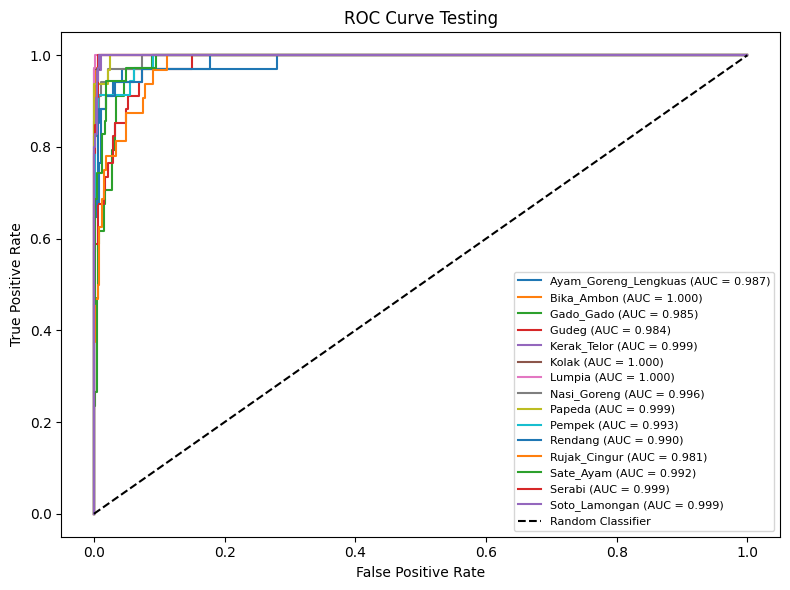

In [33]:
# ============================
# EVALUASI DATA TESTING
# ============================

# Prediksi data testing
y_test_pred = svm_model.predict(X_test_scaled)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average="weighted")
recall = recall_score(y_test, y_test_pred, average="weighted")
f1 = f1_score(y_test, y_test_pred, average="weighted")

print("========== HASIL EVALUASI TESTING ==========")
print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report
print("\nClassification Report")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=list(test_generator.class_indices.keys())
))

# ============================
# CONFUSION MATRIX
# ============================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.title("Confusion Matrix Testing")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

# ============================
# ROC-AUC
# ============================

classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_test_score = svm_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(
    y_test_bin,
    y_test_score,
    multi_class="ovr",
    average="macro"
)

print(f"\nROC-AUC Testing (Macro): {roc_auc:.4f}")

# ============================
# ROC CURVE
# ============================

plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_score[:, i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{list(test_generator.class_indices.keys())[i]} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.title("ROC Curve Testing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

SIMPAN HASIL MODEL

In [34]:
import joblib
import os

# Folder penyimpanan di Google Drive
save_path = "/content/drive/MyDrive/PROJECT AI/ESTIMASI NILAI GIZI/HASIL MODEL"

# Membuat folder jika belum ada
os.makedirs(save_path, exist_ok=True)

# Simpan model SVM
joblib.dump(svm_model, os.path.join(save_path, "svm_model.pkl"))

# Simpan StandardScaler
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))

# Simpan label kelas
joblib.dump(train_generator.class_indices,
            os.path.join(save_path, "class_indices.pkl"))

print("===================================")
print("Semua file berhasil disimpan!")
print(f"Lokasi : {save_path}")
print("===================================")

Semua file berhasil disimpan!
Lokasi : /content/drive/MyDrive/PROJECT AI/ESTIMASI NILAI GIZI/HASIL MODEL
